### IMPORTS

In [19]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

sys.path.append(os.path.abspath(".."))

from sklearn.metrics import confusion_matrix, accuracy_score

from src.dataset import get_dataloaders
from src.model import get_model

### LOAD RESULTS

In [21]:
results = {
    "baseline": {
        "val_acc": 0.50,
        "val_loss": 1.04
    },
    "augment": {
        "val_acc": 0.40,
        "val_loss": 1.06
    },
    "synthetic": {
        "val_acc": 0.50,
        "val_loss": 1.42
    },
    "combined": {
        "val_acc": 0.50,
        "val_loss": 0.87
    }
}

### RESULTS TABLE:

In [22]:
for config, vals in results.items():
    print(f"{config.upper():<10} | Val Acc: {vals['val_acc']} | Val Loss: {vals['val_loss']}")

BASELINE   | Val Acc: 0.5 | Val Loss: 1.04
AUGMENT    | Val Acc: 0.4 | Val Loss: 1.06
SYNTHETIC  | Val Acc: 0.5 | Val Loss: 1.42
COMBINED   | Val Acc: 0.5 | Val Loss: 0.87


### OBSERVATIONS OF FINAL RESULTS:  
While synthetic data improved training stability and reduced validation loss, it did not outperform the baseline in accuracy. Data augmentation significantly degraded performance, likely due to the small dataset size and the sensitivity of the classification task to subtle visual features. Combining augmentation with synthetic data further reduced performance, suggesting that excessive transformations can obscure important structural cues in residential imagery.

### SET BEST MODEL

In [47]:
best_config = "combined"

In [48]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

_, _, test_loader, classes = get_dataloaders(
                                    data_dir="../data",
                                    config=best_config)

model = get_model(num_classes=len(classes))
model.load_state_dict(torch.load(f"../outputs/models/{best_config}_model.pth"))
model.to(device)
model.eval()

/Users/emilycastelan/.venvs/pymc-env/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/emilycastelan/.venvs/pymc-env/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

### GET PREDICTIONS:

In [49]:
y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())

### COMPUTE TEST ACCURACY:

In [50]:
from sklearn.metrics import accuracy_score

test_acc = accuracy_score(y_true, y_pred)
print(f"Test Accuracy: {test_acc:.4f}")

Test Accuracy: 0.5333


### CONFUSION MATRIX:

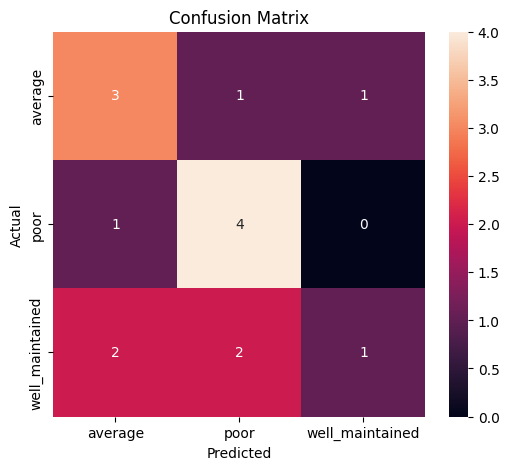

In [51]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

1. best performing class was "poor" 4/5
2. "average" class moderate 3/5 correct 2 misclassified
3. "well_maintainted" worst class 1/5 correct and 4 misclassified

**why is well_maintained the hardest to classifying?**
depends on small details
* cleanliness
* small details
* landscaping quality
* minor wear differences 
that are harder to learn with a small dataset, also the most narrow classification score between 7-8, whereas poor is 0-3, and average is 4 -6. 

**interpretation:**
The model performs best on the “poor” class due to its visually distinct features, while it struggles significantly with the “well-maintained” class. This suggests that the model is better at identifying extreme conditions but has difficulty distinguishing between higher-quality categories with more subtle visual differences.


---

## ROBUSTNESS TESTING: 

### PERTURBATIONS

In [62]:
from torchvision import transforms
import torch

# Blur
blur_transform = transforms.GaussianBlur(kernel_size=5)

# Brightness (lighting change)
brightness_transform = transforms.ColorJitter(brightness=0.5)

# Noise
def add_noise(x):
    return x + 0.1 * torch.randn_like(x)

noise_transform = transforms.Lambda(add_noise)

# Occlusion
def occlude(x):
    x = x.clone()
    _, h, w = x.shape
    x[:, h//4:h//2, w//4:w//2] = 0
    return x

occlusion_transform = transforms.Lambda(occlude)

### EVAL FUNCT.

In [63]:
def evaluate_with_transform(transform):
    preds = []
    true = []

    with torch.no_grad():
        for images, labels in test_loader:

            # APPLY TRANSFORM PER IMAGE
            images = torch.stack([transform(img) for img in images])

            images = images.to(device)

            outputs = model(images)
            _, p = torch.max(outputs, 1)

            preds.extend(p.cpu().numpy())
            true.extend(labels.numpy())

    return accuracy_score(true, preds)

### RUN ROBUSTNESS TESTING

In [64]:
baseline_acc = test_acc  # your original

blur_acc = evaluate_with_transform(blur_transform)
brightness_acc = evaluate_with_transform(brightness_transform)
noise_acc = evaluate_with_transform(noise_transform)
occlusion_acc = evaluate_with_transform(occlusion_transform)

print("Baseline:", baseline_acc)
print("Blur:", blur_acc)
print("Brightness:", brightness_acc)
print("Noise:", noise_acc)
print("Occlusion:", occlusion_acc)

Baseline: 0.5333333333333333
Blur: 0.4666666666666667
Brightness: 0.4
Noise: 0.6
Occlusion: 0.6666666666666666


#### OBSERVATIONS:
The model is overfitting to irrelevant features. 
There may be background bias, even though I tried to vary the backgrounds.
It might be learning from noise like vehicles in images. 
Then occulusion is focing the model to focus more on house structure. 

**overall:**
This behavior indicates potential overfitting to spurious correlations in the dataset, where the model learns patterns that are not directly related to the classification task. The improvement under occlusion further suggests that certain regions of the image may contain misleading information that negatively impacts prediction performance when left unaltered.  
While the model is learning something meaningful and can generalize somewhat, it may be relying on weak features and struggles to grasp true feature importance.

### 